In [2]:
import fastf1 
import fastf1.plotting

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
session = fastf1.get_session(2026, 3, 'Q')
session.load()

session.name

req         WARNING 	DEFAULT CACHE ENABLED! (48.1 MB) C:\Users\arkan\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '81', '16', '1', '44', '10', '6', '5', '41', '3', '31', '27', '30', '43', '55', '23', '87', '11', '77', '14', '18']


'Qualifying'

In [4]:
session.event

RoundNumber                                                  3
Country                                                  Japan
Location                                                Suzuka
OfficialEventName    FORMULA 1 ARAMCO JAPANESE GRAND PRIX 2026
EventDate                                  2026-03-29 00:00:00
EventName                                  Japanese Grand Prix
EventFormat                                       conventional
Session1                                            Practice 1
Session1Date                         2026-03-27 11:30:00+09:00
Session1DateUtc                            2026-03-27 02:30:00
Session2                                            Practice 2
Session2Date                         2026-03-27 15:00:00+09:00
Session2DateUtc                            2026-03-27 06:00:00
Session3                                            Practice 3
Session3Date                         2026-03-28 11:30:00+09:00
Session3DateUtc                            2026-03-28 0

In [5]:
session.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,1.0,,NaN,0 days 00:01:30.035000,0 days 00:01:29.048000,0 days 00:01:28.778000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,2.0,,NaN,0 days 00:01:29.967000,0 days 00:01:29.686000,0 days 00:01:29.076000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,3.0,,NaN,0 days 00:01:30.200000,0 days 00:01:29.451000,0 days 00:01:29.132000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,,NaN,0 days 00:01:29.915000,0 days 00:01:29.303000,0 days 00:01:29.405000,NaT,,NaN,NaN
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,5.0,,NaN,0 days 00:01:30.401000,0 days 00:01:29.795000,0 days 00:01:29.409000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,6.0,,NaN,0 days 00:01:30.309000,0 days 00:01:29.589000,0 days 00:01:29.567000,NaT,,NaN,NaN
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,7.0,,NaN,0 days 00:01:30.584000,0 days 00:01:29.874000,0 days 00:01:29.691000,NaT,,NaN,NaN
6,6,I HADJAR,HAD,hadjar,Red Bull Racing,4781D7,red_bull,Isack,Hadjar,Isack Hadjar,...,8.0,,NaN,0 days 00:01:30.662000,0 days 00:01:30.104000,0 days 00:01:29.978000,NaT,,NaN,NaN
5,5,G BORTOLETO,BOR,bortoleto,Audi,F50537,audi,Gabriel,Bortoleto,Gabriel Bortoleto,...,9.0,,NaN,0 days 00:01:30.359000,0 days 00:01:29.990000,0 days 00:01:30.274000,NaT,,NaN,NaN
41,41,A LINDBLAD,LIN,arvid_lindblad,Racing Bulls,6C98FF,rb,Arvid,Lindblad,Arvid Lindblad,...,10.0,,NaN,0 days 00:01:30.781000,0 days 00:01:30.109000,0 days 00:01:30.319000,NaT,,NaN,NaN


In [6]:
dvr_1 = 'VER'
dvr_2 = 'PIA'

dvr_1_lap = session.laps.pick_drivers(dvr_1).pick_fastest()
dvr_2_lap = session.laps.pick_drivers(dvr_2).pick_fastest()

dvr_1_tel = dvr_1_lap.get_car_data().add_distance()
dvr_2_tel = dvr_2_lap.get_car_data().add_distance()

dvr_1_team_col = fastf1.plotting.get_team_color(dvr_1_lap['Team'], session=session)
dvr_2_team_col = fastf1.plotting.get_team_color(dvr_2_lap['Team'], session=session)

req            INFO 	Using cached data for driver_info


C:\Users\arkan\AppData\Local\Temp\ipykernel_24040\3685666658.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


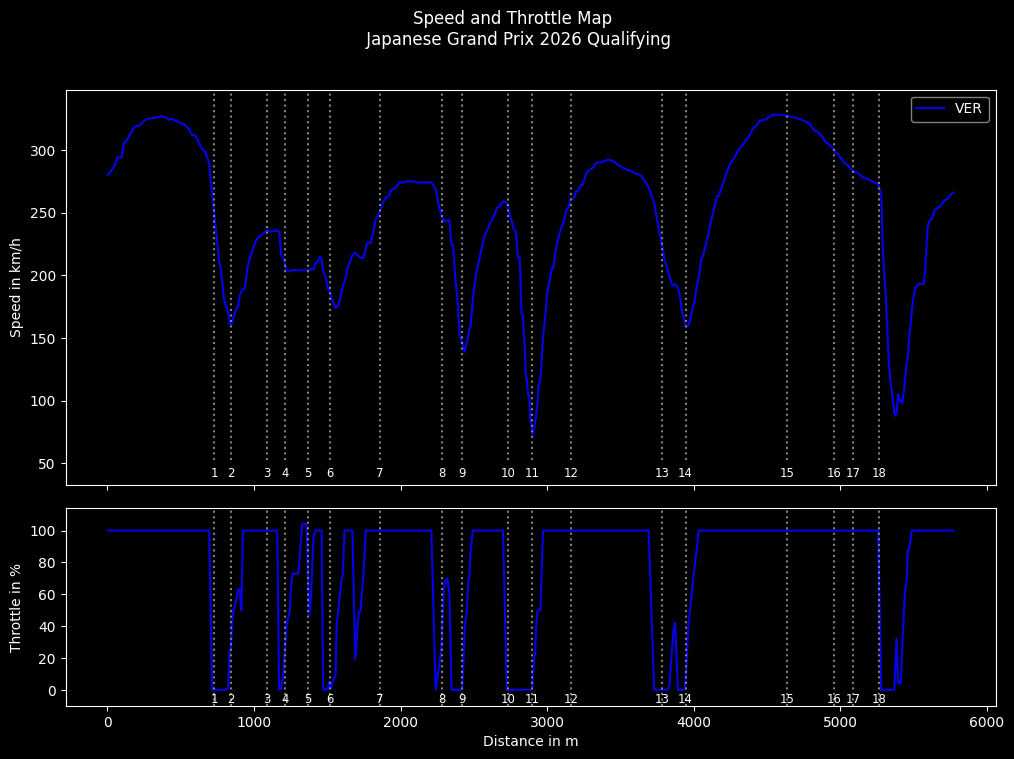

In [9]:
# Prepare circuit info for a combined speed and throttle view
circuit_info = session.get_circuit_info()

fig, (ax_speed, ax_throttle) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08}
)
fig.patch.set_facecolor('black')

for ax in (ax_speed, ax_throttle):
    ax.set_facecolor('black')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    for spine in ax.spines.values():
        spine.set_color('white')

ax_speed.plot(
    dvr_1_tel['Distance'],
    dvr_1_tel['Speed'],
    color=dvr_1_team_col,
    label=dvr_1
)

ax_throttle.plot(
    dvr_1_tel['Distance'],
    dvr_1_tel['Throttle'],
    color=dvr_1_team_col,
    label=dvr_1
)

ax_speed.set_ylabel('Speed in km/h', color='white')
ax_throttle.set_ylabel('Throttle in %', color='white')
ax_throttle.set_xlabel('Distance in m', color='white')

legend = ax_speed.legend(
    facecolor='black', edgecolor='white', labelcolor='white', framealpha=0.5
)
for text in legend.get_texts():
    text.set_color('white')

plt.suptitle(f"Speed and Throttle Map \n "
             f"{session.event['EventName']} {session.event.year} Qualifying", color='white')

speed_min = dvr_1_tel['Speed'].min()
speed_max = dvr_1_tel['Speed'].max()
throttle_min = dvr_1_tel['Throttle'].min()
throttle_max = dvr_1_tel['Throttle'].max()

ax_speed.vlines(
    x=circuit_info.corners['Distance'], ymin=speed_min - 20, ymax=speed_max + 20,
    linestyles='dotted', colors='grey'
)
ax_throttle.vlines(
    x=circuit_info.corners['Distance'], ymin=throttle_min - 10, ymax=throttle_max + 10,
    linestyles='dotted', colors='grey'
)

for _, corner in circuit_info.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    ax_speed.text(
        corner['Distance'], speed_min - 30, txt,
        va='center_baseline', ha='center', size='small', color='white'
    )
    ax_throttle.text(
        corner['Distance'], throttle_min - 5, txt,
        va='center_baseline', ha='center', size='small', color='white'
    )

ax_speed.set_ylim([speed_min - 40, speed_max + 20])
ax_throttle.set_ylim([throttle_min - 10, throttle_max + 10])

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


In [19]:
dvr_1_tel[dvr_1_tel['Throttle'] > 100]


,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
71,2026-03-28 06:37:24.885,11055.0,204.0,5,104.0,True,0,car,0 days 00:00:19.037000,0 days 00:48:57.447000,1328.793611
72,2026-03-28 06:37:25.045,11055.0,204.0,5,104.0,True,0,car,0 days 00:00:19.197000,0 days 00:48:57.607000,1337.860278
73,2026-03-28 06:37:25.206,11055.0,204.0,5,104.0,True,0,car,0 days 00:00:19.358000,0 days 00:48:57.768000,1346.983611
74,2026-03-28 06:37:25.406,11055.0,204.0,5,104.0,True,0,car,0 days 00:00:19.558000,0 days 00:48:57.968000,1358.316944


In [ ]:
# Throttle is now included in the combined speed/throttle plot above.
